In [ ]:
import pickle

import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import f_oneway, shapiro
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from statsmodels.stats.multicomp import MultiComparison

In [ ]:
models={}

# Avaliação dos algoritmos

## Tuning dos parâmetros com GridSearch

### Preparação dos dados

Comece recarregando as variáveis `X` e `y`, dos splits `train` e `test`, a partir do arquivo salvo `cover_type.pkl`.

In [ ]:
with open('./Variaveis/cover_type.pkl', 'rb') as f:
    X_train, y_train, X_test, y_test = pickle.load(f)

Inspecione o `shape` desses objetos.

In [ ]:
X_train.shape, y_train.shape

((7500, 53), (7500,))

In [ ]:
X_test.shape, y_test.shape

((2500, 53), (2500,))

Junte as variáveis preditoras em uma única variável `X`, e inspecione seu `shape`.

In [ ]:
X = np.concatenate((X_train, X_test), axis=0)
X.shape

(10000, 53)

Junte a variável alvo em uma única variável `y`, e inspecione seu `shape`.

In [ ]:
y = np.concatenate((y_train, y_test), axis=0)
y.shape

(10000,)

### Árvore de decisão

Estabeleça um dicionário `parameters` com os parâmetros a investigar durante o Grid Search. Você pode usar os mesmos parâmetros utilizados na aula, ou outros parâmetros. Para escolher outros parâmetros, visualize as possibilidades na documentação da classe `DecisionTreeClassifier`.

In [ ]:
parametros = {'criterion': ['gini', 'entropy'],
              'splitter': ['best', 'random'],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 5, 10]}

Crie uma instância da classe `GridSearch`, informando uma instância de `DecisionTreeClassifier` como o estimador, e os parâmetros definidos acima como grid de pesquisa. Inclua os parâmetros `verbose=True` para exibir informações sobre o processo, e `n_jobs=-1` para fazer a pesquisa de parâmetros de forma paralela, utilizando todas as CPUs disponíveis no ambiente de computação. Desta vez, salve a instância com o nome `grid_search_tree`, porque você vai utilizar os resultados do Grid Search mais pra frente.

In [ ]:
grid_search_tree = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=parametros, verbose=True, n_jobs=-1)

Faça o ajuste dessa instância, passando as variáveis `X` e `y`.

In [ ]:
grid_search_tree.fit(X, y)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 5, ...], 'splitter': ['best', 'random']}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


Recupere os melhores parâmetros e os melhores resultados, e exiba esses valores.

In [ ]:
melhores_parametros = grid_search_tree.best_params_
melhor_resultado = grid_search_tree.best_score_

In [ ]:
models['DecisionTreeClassifier']=melhores_parametros, {'model_class': DecisionTreeClassifier}
models

{'DecisionTreeClassifier': ({'criterion': 'gini',
   'min_samples_leaf': 1,
   'min_samples_split': 5,
   'splitter': 'random'},
  {'model_class': sklearn.tree._classes.DecisionTreeClassifier})}

In [ ]:
print(melhores_parametros)
print(f'{melhor_resultado:.4f}')

{'criterion': 'gini', 'min_samples_leaf': 1, 'min_samples_split': 5, 'splitter': 'random'}
0.7276


### Random forest

Repita o exercício utilizando `RandomForestClassifier`. Também chame a instância de `GridSearchCV` fazendo referência ao nome do algoritmo utilizado.

In [ ]:
parametros = {'criterion':['gini', 'entropy'],
              'n_estimators': [10, 40, 100, 150],
              'min_samples_split': [2,5,10],
              'min_samples_leaf':[1,5,10],
              'random_state':[0,42]}

In [ ]:
grid_search_rf = GridSearchCV(estimator=RandomForestClassifier(), param_grid=parametros, n_jobs=-1, verbose=True)

In [ ]:
grid_search_rf.fit(X,y)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


,estimator,RandomForestClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [10, 40, ...], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,150


In [ ]:
melhores_parametros = grid_search_rf.best_params_
melhor_resultado = grid_search_rf.best_score_

In [ ]:
models['RandomForestClassifier']=melhores_parametros, {'model_class': RandomForestClassifier}
models

{'DecisionTreeClassifier': ({'criterion': 'gini',
   'min_samples_leaf': 1,
   'min_samples_split': 5,
   'splitter': 'random'},
  {'model_class': sklearn.tree._classes.DecisionTreeClassifier}),
 'RandomForestClassifier': ({'criterion': 'entropy',
   'min_samples_leaf': 1,
   'min_samples_split': 2,
   'n_estimators': 150,
   'random_state': 42},
  {'model_class': sklearn.ensemble._forest.RandomForestClassifier})}

In [ ]:
print(melhores_parametros)
print(f'{melhor_resultado:.4f}')

{'criterion': 'entropy', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150, 'random_state': 42}
0.8186


### KNN

Repita o exercício utilizando `KNeighborsClassifier`.

In [ ]:
parametros = {'n_neighbors': [3, 5, 10, 20],
              'p': [1, 2]}

In [ ]:
grid_search_knn = GridSearchCV(estimator=KNeighborsClassifier(),param_grid=parametros, n_jobs=-1, verbose=True)

In [ ]:
grid_search_knn.fit(X,y)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...], 'p': [1, 2]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,3


In [ ]:
melhor_resultado = grid_search_knn.best_score_
melhores_parametros = grid_search_knn.best_params_

In [ ]:
models['KNeighborsClassifier']=melhores_parametros, {'model_class': KNeighborsClassifier}
models

{'DecisionTreeClassifier': ({'criterion': 'gini',
   'min_samples_leaf': 1,
   'min_samples_split': 5,
   'splitter': 'random'},
  {'model_class': sklearn.tree._classes.DecisionTreeClassifier}),
 'RandomForestClassifier': ({'criterion': 'entropy',
   'min_samples_leaf': 1,
   'min_samples_split': 2,
   'n_estimators': 150,
   'random_state': 42},
  {'model_class': sklearn.ensemble._forest.RandomForestClassifier}),
 'KNeighborsClassifier': ({'n_neighbors': 3, 'p': 1},
  {'model_class': sklearn.neighbors._classification.KNeighborsClassifier})}

In [ ]:
print(melhores_parametros)
print(f"{melhor_resultado:.4f}")


{'n_neighbors': 3, 'p': 1}
0.7678


### Regressão logística

Repita o exercício utilizando `LogisticRegression`.

In [ ]:
parametros = {'tol': [0.0001, 0.00001, 0.000001],
              'C': [1.0, 1.5, 2.0],
              'solver': ['lbfgs', 'sag', 'saga']}

In [ ]:
grid_search_lr = GridSearchCV(estimator=LogisticRegression(), param_grid=parametros, n_jobs=-1, verbose=True)

In [ ]:
grid_search_lr.fit(X,y)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


f:\Python Venv\Machine_Learning\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,estimator,LogisticRegression()
,param_grid,"{'C': [1.0, 1.5, ...], 'solver': ['lbfgs', 'sag', ...], 'tol': [0.0001, 1e-05, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [ ]:
melhores_parametros = grid_search_lr.best_params_
melhor_resultado = grid_search_lr.best_score_

In [ ]:
models['LogisticRegression']=melhores_parametros, {'model_class': LogisticRegression}
models

{'DecisionTreeClassifier': ({'criterion': 'gini',
   'min_samples_leaf': 1,
   'min_samples_split': 5,
   'splitter': 'random'},
  {'model_class': sklearn.tree._classes.DecisionTreeClassifier}),
 'RandomForestClassifier': ({'criterion': 'entropy',
   'min_samples_leaf': 1,
   'min_samples_split': 2,
   'n_estimators': 150,
   'random_state': 42},
  {'model_class': sklearn.ensemble._forest.RandomForestClassifier}),
 'KNeighborsClassifier': ({'n_neighbors': 3, 'p': 1},
  {'model_class': sklearn.neighbors._classification.KNeighborsClassifier}),
 'LogisticRegression': ({'C': 2.0, 'solver': 'lbfgs', 'tol': 0.0001},
  {'model_class': sklearn.linear_model._logistic.LogisticRegression})}

In [ ]:
print(melhores_parametros)
print(f"{melhor_resultado:.4f}")

{'C': 2.0, 'solver': 'lbfgs', 'tol': 0.0001}
0.7225


### SVM

Repita o exercício utilizando `SVC`.

In [ ]:
parametros = {'tol': [0.001, 0.0001, 0.00001],
              'C': [1.0, 1.5, 2.0],
              'kernel': ['rbf', 'linear', 'poly', 'sigmoid']}

In [ ]:
grid_search_svm = GridSearchCV(estimator=SVC(), param_grid=parametros, n_jobs=-1, verbose=True)
grid_search_svm.fit(X,y)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,estimator,SVC()
,param_grid,"{'C': [1.0, 1.5, ...], 'kernel': ['rbf', 'linear', ...], 'tol': [0.001, 0.0001, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,2.0


In [ ]:
melhores_parametros = grid_search_svm.best_params_
melhor_resultado = grid_search_svm.best_score_

In [ ]:
models['SVC']=melhores_parametros, {'model_class': SVC}
models

{'DecisionTreeClassifier': ({'criterion': 'gini',
   'min_samples_leaf': 1,
   'min_samples_split': 5,
   'splitter': 'random'},
  {'model_class': sklearn.tree._classes.DecisionTreeClassifier}),
 'RandomForestClassifier': ({'criterion': 'entropy',
   'min_samples_leaf': 1,
   'min_samples_split': 2,
   'n_estimators': 150,
   'random_state': 42},
  {'model_class': sklearn.ensemble._forest.RandomForestClassifier}),
 'KNeighborsClassifier': ({'n_neighbors': 3, 'p': 1},
  {'model_class': sklearn.neighbors._classification.KNeighborsClassifier}),
 'LogisticRegression': ({'C': 2.0, 'solver': 'lbfgs', 'tol': 0.0001},
  {'model_class': sklearn.linear_model._logistic.LogisticRegression}),
 'SVC': ({'C': 2.0, 'kernel': 'rbf', 'tol': 0.0001},
  {'model_class': sklearn.svm._classes.SVC})}

In [ ]:
print(melhores_parametros)
print(f"{melhor_resultado:.4f}")

{'C': 2.0, 'kernel': 'rbf', 'tol': 0.0001}
0.7734


### Rede neural

Repita o exercício utilizando `MLPClassifier`.

In [ ]:
parametros = {'activation': ['relu', 'logistic', 'tanh'],
              'solver': ['adam', 'sgd'],
              'batch_size': [5, 10, 15, 56],
              'max_iter': [200, 500]}

In [ ]:
grid_search_nn = GridSearchCV(estimator=MLPClassifier(), param_grid=parametros, verbose=True, n_jobs=-1)

In [ ]:
grid_search_nn.fit(X,y)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


f:\Python Venv\Machine_Learning\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,estimator,MLPClassifier()
,param_grid,"{'activation': ['relu', 'logistic', ...], 'batch_size': [5, 10, ...], 'max_iter': [200, 500], 'solver': ['adam', 'sgd']}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,hidden_layer_sizes,"(100,)"


In [ ]:
melhores_parametros = grid_search_nn.best_params_
melhor_resultado = grid_search_nn.best_score_

In [ ]:
models['MLPClassifier']=melhores_parametros, {'model_class': MLPClassifier}
models

{'DecisionTreeClassifier': ({'criterion': 'gini',
   'min_samples_leaf': 1,
   'min_samples_split': 5,
   'splitter': 'random'},
  {'model_class': sklearn.tree._classes.DecisionTreeClassifier}),
 'RandomForestClassifier': ({'criterion': 'entropy',
   'min_samples_leaf': 1,
   'min_samples_split': 2,
   'n_estimators': 150,
   'random_state': 42},
  {'model_class': sklearn.ensemble._forest.RandomForestClassifier}),
 'KNeighborsClassifier': ({'n_neighbors': 3, 'p': 1},
  {'model_class': sklearn.neighbors._classification.KNeighborsClassifier}),
 'LogisticRegression': ({'C': 2.0, 'solver': 'lbfgs', 'tol': 0.0001},
  {'model_class': sklearn.linear_model._logistic.LogisticRegression}),
 'SVC': ({'C': 2.0, 'kernel': 'rbf', 'tol': 0.0001},
  {'model_class': sklearn.svm._classes.SVC}),
 'MLPClassifier': ({'activation': 'logistic',
   'batch_size': 56,
   'max_iter': 500,
   'solver': 'adam'},
  {'model_class': sklearn.neural_network._multilayer_perceptron.MLPClassifier})}

In [ ]:
print(melhores_parametros)
print(f"{melhor_resultado:.4f}")

{'activation': 'logistic', 'batch_size': 56, 'max_iter': 500, 'solver': 'adam'}
0.7919


## Validação cruzada

Agora repita o exemplo da validação cruzada, usando o mesmo método e os mesmos parâmetros utilizados na aula. Entretanto, para limitar o tempo de execução, estou deixando comentados os algoritmos DecisionTree e SVM, e repetindo por apenas 10 loops. Você pode modificar esses valores se quiser.

In [ ]:
teste = dict(list(models.items())[0:2])

In [ ]:
i=0
resultados ={}
#lista=[]
for model, (parametros, model_class) in models.items():
    print(f'Modelo: {model}')
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)

    modelo = model_class['model_class']
    classificador= modelo(**parametros)
    scores = cross_val_score(classificador, X,y, cv=kfold)
    print(f'Scores: {scores}')
    resultados[model]=scores

    i=i+1


Modelo: DecisionTreeClassifier
Scores: [0.739 0.729 0.74  0.74  0.72  0.731 0.71  0.723 0.724 0.737]
Modelo: RandomForestClassifier
Scores: [0.828 0.813 0.82  0.822 0.82  0.847 0.833 0.799 0.817 0.796]
Modelo: KNeighborsClassifier
Scores: [0.771 0.758 0.774 0.763 0.765 0.771 0.776 0.762 0.788 0.765]
Modelo: LogisticRegression


f:\Python Venv\Machine_Learning\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
f:\Python Venv\Machine_Learning\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html


Scores: [0.744 0.742 0.754 0.711 0.701 0.71  0.725 0.728 0.705 0.724]
Modelo: SVC
Scores: [0.779 0.746 0.777 0.784 0.793 0.777 0.759 0.782 0.767 0.788]
Modelo: MLPClassifier


f:\Python Venv\Machine_Learning\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
f:\Python Venv\Machine_Learning\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
f:\Python Venv\Machine_Learning\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
f:\Python Venv\Machine_Learning\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
f:\Python Venv\Machine_Learning\Lib\site-pac

Scores: [0.785 0.795 0.804 0.802 0.782 0.792 0.794 0.819 0.797 0.812]


f:\Python Venv\Machine_Learning\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
resultados

{'DecisionTreeClassifier': array([0.739, 0.729, 0.74 , 0.74 , 0.72 , 0.731, 0.71 , 0.723, 0.724,
        0.737]),
 'RandomForestClassifier': array([0.828, 0.813, 0.82 , 0.822, 0.82 , 0.847, 0.833, 0.799, 0.817,
        0.796]),
 'KNeighborsClassifier': array([0.771, 0.758, 0.774, 0.763, 0.765, 0.771, 0.776, 0.762, 0.788,
        0.765]),
 'LogisticRegression': array([0.744, 0.742, 0.754, 0.711, 0.701, 0.71 , 0.725, 0.728, 0.705,
        0.724]),
 'SVC': array([0.779, 0.746, 0.777, 0.784, 0.793, 0.777, 0.759, 0.782, 0.767,
        0.788]),
 'MLPClassifier': array([0.785, 0.795, 0.804, 0.802, 0.782, 0.792, 0.794, 0.819, 0.797,
        0.812])}

Consolide os resultados em um DataFrame, com o nome do método sendo o rótulo das colunas.

In [ ]:
results = pd.DataFrame(resultados)
results

,DecisionTreeClassifier,RandomForestClassifier,KNeighborsClassifier,LogisticRegression,SVC,MLPClassifier
0,0.739,0.828,0.771,0.744,0.779,0.785
1,0.729,0.813,0.758,0.742,0.746,0.795
2,0.740,0.820,0.774,0.754,0.777,0.804
3,0.740,0.822,0.763,0.711,0.784,0.802
4,0.720,0.820,0.765,0.701,0.793,0.782
5,0.731,0.847,0.771,0.710,0.777,0.792
6,0.710,0.833,0.776,0.725,0.759,0.794
7,0.723,0.799,0.762,0.728,0.782,0.819
8,0.724,0.817,0.788,0.705,0.767,0.797
9,0.737,0.796,0.765,0.724,0.788,0.812


Exiba as estatísticas básicas para cada método no DataFrame.

In [ ]:
results.describe()

,DecisionTreeClassifier,RandomForestClassifier,KNeighborsClassifier,LogisticRegression,SVC,MLPClassifier
count,10.000000,10.00000,10.000000,10.000000,10.000000,10.000000
mean,0.729300,0.81950,0.769300,0.724400,0.775200,0.798200
std,0.010067,0.01505,0.008693,0.017933,0.014172,0.011429
min,0.710000,0.79600,0.758000,0.701000,0.746000,0.782000
25%,0.723250,0.81400,0.763500,0.710250,0.769500,0.792500
50%,0.730000,0.82000,0.768000,0.724500,0.778000,0.796000
75%,0.738500,0.82650,0.773250,0.738500,0.783500,0.803500
max,0.740000,0.84700,0.788000,0.754000,0.793000,0.819000


Exiba a variância de cada método.

In [ ]:
results.var()

DecisionTreeClassifier    0.000101
RandomForestClassifier    0.000226
KNeighborsClassifier      0.000076
LogisticRegression        0.000322
SVC                       0.000201
MLPClassifier             0.000131
dtype: float64

Exiba o desvio padrão dividido pela média de cada método, como um valor percentual.

In [ ]:
(results.std() / results.mean()) * 100

DecisionTreeClassifier    1.380364
RandomForestClassifier    1.836476
KNeighborsClassifier      1.129976
LogisticRegression        2.475595
SVC                       1.828168
MLPClassifier             1.431848
dtype: float64

## Teste de normalidade

Use o método de Shapiro para determinar se os resultados podem ser considerados amostras de uma distribuição normal.

In [ ]:
for result, values in results.items():
    print(result)
    print(f'{shapiro(values)}')

DecisionTreeClassifier
ShapiroResult(statistic=np.float64(0.9155024529317584), pvalue=np.float64(0.3209640749402741))
RandomForestClassifier
ShapiroResult(statistic=np.float64(0.9615665583275995), pvalue=np.float64(0.803578305261005))
KNeighborsClassifier
ShapiroResult(statistic=np.float64(0.9302014394166092), pvalue=np.float64(0.4498764834064113))
LogisticRegression
ShapiroResult(statistic=np.float64(0.9422624606152297), pvalue=np.float64(0.578452276006655))
SVC
ShapiroResult(statistic=np.float64(0.9228442144217307), pvalue=np.float64(0.38128872738782804))
MLPClassifier
ShapiroResult(statistic=np.float64(0.9685943686501922), pvalue=np.float64(0.8775152122727878))


Exiba um gráfico dos resultados utilizando a função `sns.displot`.

In [ ]:
import matplotlib.pyplot as plt

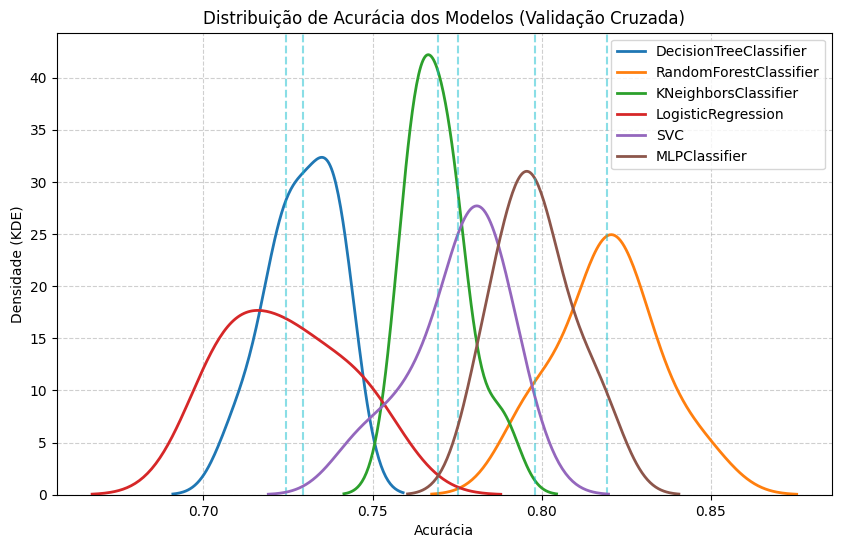

In [ ]:
# 1. Configurações iniciais (tamanho do gráfico)
plt.figure(figsize=(10, 6))
plt.title('Distribuição de Acurácia dos Modelos (Validação Cruzada)')
plt.xlabel('Acurácia')
plt.ylabel('Densidade (KDE)')

for nome_modelo, scores in results.items():

    sns.kdeplot(scores, label=nome_modelo, linewidth=2)

    # Opcional: Adicionar uma linha vertical na média de cada modelo
    plt.axvline(np.mean(scores), color=sns.color_palette()[-1], linestyle='--', alpha=0.5)

# 3. Exibe a legenda e o grid
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Teste de hipótese com ANOVA e Tukey

Utilize o método ANOVA (one way) para determinar se os resultados são estatisticamente iguais ou se existe pelo menos um resultado diferente.

In [ ]:
grupos = resultados.values()
f_statistic, p = f_oneway(*grupos)
print(f"Estatística F (ANOVA): {f_statistic:.4f}")
print(f"Valor P: {p:.4e}")

Estatística F (ANOVA): 79.5784
Valor P: 1.1529e-23


Considerando $alpha = 0.5$, qual a conclusão do teste?

Agora vamos utilizar o método `melt` do Pandas para reorganizar o dataframe de resultados.

In [ ]:
results_df = results.melt(var_name='algorithm', value_name='accuracy')
results_df

,algorithm,accuracy
0,DecisionTreeClassifier,0.739
1,DecisionTreeClassifier,0.729
2,DecisionTreeClassifier,0.740
3,DecisionTreeClassifier,0.740
4,DecisionTreeClassifier,0.720
5,DecisionTreeClassifier,0.731
6,DecisionTreeClassifier,0.710
7,DecisionTreeClassifier,0.723
8,DecisionTreeClassifier,0.724
9,DecisionTreeClassifier,0.737


Utilize a classe `MultiComparison` para criar uma instância que será utilizada como base para comparar os algoritmos e seus resultados.

In [ ]:
compare_algorithms = MultiComparison(results_df.accuracy, results_df.algorithm)

Utilize essa instância para determinar os resultados do teste de Tukey. Exiba os resultados.

In [ ]:
statistical_test = compare_algorithms.tukeyhsd()
print(statistical_test)

                Multiple Comparison of Means - Tukey HSD, FWER=0.05                 
        group1                 group2         meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------------------
DecisionTreeClassifier   KNeighborsClassifier     0.04    0.0  0.0225  0.0575   True
DecisionTreeClassifier     LogisticRegression  -0.0049 0.9615 -0.0224  0.0126  False
DecisionTreeClassifier          MLPClassifier   0.0689    0.0  0.0514  0.0864   True
DecisionTreeClassifier RandomForestClassifier   0.0902    0.0  0.0727  0.1077   True
DecisionTreeClassifier                    SVC   0.0459    0.0  0.0284  0.0634   True
  KNeighborsClassifier     LogisticRegression  -0.0449    0.0 -0.0624 -0.0274   True
  KNeighborsClassifier          MLPClassifier   0.0289 0.0001  0.0114  0.0464   True
  KNeighborsClassifier RandomForestClassifier   0.0502    0.0  0.0327  0.0677   True
  KNeighborsClassifier                    SVC   0.0059 0.9178 -0.

Exiba a média dos resultados.

In [ ]:
results.mean()

DecisionTreeClassifier    0.7293
RandomForestClassifier    0.8195
KNeighborsClassifier      0.7693
LogisticRegression        0.7244
SVC                       0.7752
MLPClassifier             0.7982
dtype: float64

Exiba os resultados do teste estatístico em um plot.

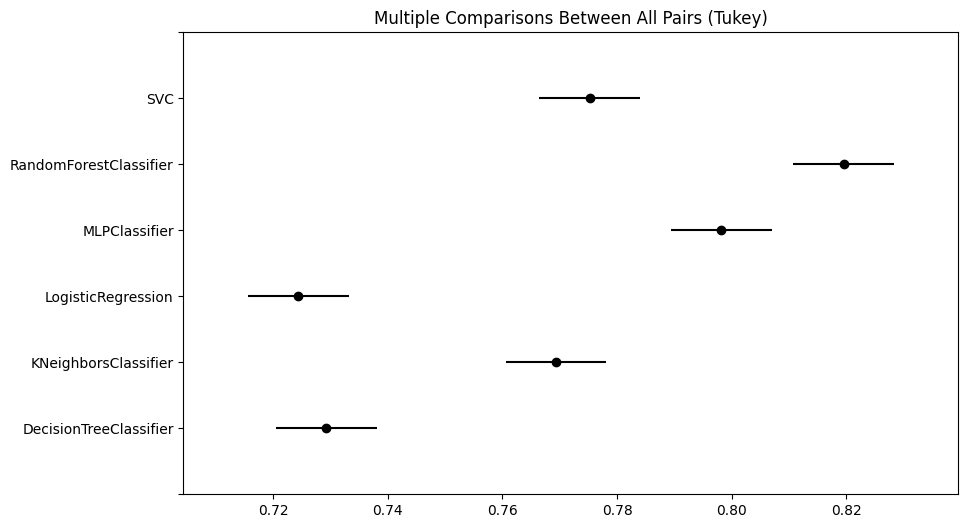

In [ ]:
statistical_test.plot_simultaneous();

Quais conclusões são possíveis a partir desses resultados?

## Salvar um classificador treinado

Ao invés de retreinar um modelo, desta vez nós vamos recuperar um modelo já treinado anteriormente. Se você executou os exercícios até aqui, as instâncias de `GridSearchCV` contêm os melhores modelos encontrados no parâmetro `best_estimator_`. Vamos recuperar estes modelos.

In [ ]:
tree = grid_search_tree.best_estimator_
tree

,criterion,'gini'
,splitter,'random'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
rf = grid_search_rf.best_estimator_
rf

,n_estimators,150
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
knn = grid_search_knn.best_estimator_
knn

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [ ]:
lr = grid_search_lr.best_estimator_
lr

,penalty,'l2'
,dual,False
,tol,0.0001
,C,2.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
svm = grid_search_svm.best_estimator_
svm

,C,2.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.0001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
neural_net = grid_search_nn.best_estimator_
neural_net

,hidden_layer_sizes,"(100,)"
,activation,'logistic'
,solver,'adam'
,alpha,0.0001
,batch_size,56
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,None


Salve os classificadores na pasta do Drive.

In [ ]:
pickle.dump(tree, open("./Variaveis/tree.sav", "wb"))
pickle.dump(rf, open("./Variaveis/rf.sav", "wb"))
pickle.dump(knn, open("./Variaveis/knn.sav", "wb"))
pickle.dump(lr, open("./Variaveis/lr.sav", "wb"))
pickle.dump(svm, open("./Variaveis/svm.sav", "wb"))
pickle.dump(neural_net, open("./Variaveis/neural_net.sav", "wb"))

Nós vamos recarregar e utilizar os modelos para fazer predições no próximo exercício.